# RetailPulse - Week 3 Checkpoint

## AI-Powered Customer Analytics & Demand Forecasting Platform

### Week 3 Objectives
- Day 15: Streamlit dashboard skeleton with multi-page layout
- Day 16: Demand forecasting visualisations and what-if analysis
- Day 17: Customer segmentation and churn risk dashboard
- Day 18: Inventory optimization recommendations UI
- Day 19: Real-time metrics and alerts
- Day 20: Export functionality (CSV / PDF reports)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## Step 1: Verify All Dashboard Files Exist

In [2]:
dashboard_root = "../retailpulse_dashboard"

expected_files = [
    "app.py",
    "utils/data_loader.py",
    "pages/1_Demand_Forecasting.py",
    "pages/2_Customer_Segmentation.py",
    "pages/3_Inventory_Optimization.py",
    "pages/4_Metrics_and_Alerts.py",
    "pages/5_Export_Reports.py",
    "requirements.txt"
]

file_status = []

for f in expected_files:
    full_path = os.path.join(dashboard_root, f)
    exists = os.path.exists(full_path)
    size_kb = round(os.path.getsize(full_path) / 1024, 1) if exists else 0
    file_status.append({
        "File": f,
        "Status": "✅ Present" if exists else "❌ Missing",
        "Size (KB)": size_kb
    })

files_df = pd.DataFrame(file_status)

print(files_df.to_string(index=False))

                             File    Status  Size (KB)
                           app.py ✅ Present        7.4
             utils/data_loader.py ✅ Present        2.8
    pages/1_Demand_Forecasting.py ✅ Present       15.6
 pages/2_Customer_Segmentation.py ✅ Present       17.1
pages/3_Inventory_Optimization.py ✅ Present       16.6
    pages/4_Metrics_and_Alerts.py ✅ Present       18.5
        pages/5_Export_Reports.py ✅ Present       19.2
                 requirements.txt ✅ Present        0.2


## Step 2: Verify All Required Data Files Exist

In [3]:
data_files = [
    # Week 1
    ("cleaned_retail.csv",             "Week 1 - Day 2"),
    ("rfm_segmented.csv",              "Week 1 - Day 3"),
    ("daily_sales.csv",                "Week 1 - Day 4"),
    ("forecast_results.csv",           "Week 1 - Day 5"),
    ("lstm_predictions.csv",           "Week 1 - Day 6"),
    # Week 2
    ("ensemble_forecast_results.csv",  "Week 2 - Day 8"),
    ("ensemble_future_30_days.csv",    "Week 2 - Day 8"),
    ("ensemble_metrics.csv",           "Week 2 - Day 8"),
    ("churn_predictions.csv",          "Week 2 - Day 9"),
    ("churn_metrics.csv",              "Week 2 - Day 9"),
    ("inventory_projection.csv",       "Week 2 - Day 10"),
    ("inventory_summary.csv",          "Week 2 - Day 10"),
    ("churn_predictions_tuned.csv",    "Week 2 - Day 11"),
    ("optuna_tuning_summary.csv",      "Week 2 - Day 11"),
    ("optuna_best_params.csv",         "Week 2 - Day 11"),
    ("drift_column_results.csv",       "Week 2 - Day 12"),
    ("drift_monitor_summary.csv",      "Week 2 - Day 12"),
    ("retraining_log.csv",             "Week 2 - Day 13"),
    ("week2_targets_summary.csv",      "Week 2 - Day 14"),
]

data_status = []

for filename, source in data_files:
    full_path = os.path.join("../data", filename)
    exists = os.path.exists(full_path)
    size_kb = round(os.path.getsize(full_path) / 1024, 1) if exists else 0
    data_status.append({
        "File": filename,
        "Source": source,
        "Status": "✅" if exists else "❌ Missing",
        "Size (KB)": size_kb
    })

data_df = pd.DataFrame(data_status)

print(data_df.to_string(index=False))

missing = data_df[data_df["Status"] == "❌ Missing"]
if len(missing):
    print(f"\n⚠️  {len(missing)} file(s) missing — run the corresponding notebooks.")
else:
    print("\n✅ All data files present.")

                         File          Source Status  Size (KB)
           cleaned_retail.csv  Week 1 - Day 2      ✅    49451.5
            rfm_segmented.csv  Week 1 - Day 3      ✅      139.2
              daily_sales.csv  Week 1 - Day 4      ✅        6.4
         forecast_results.csv  Week 1 - Day 5      ✅      100.1
         lstm_predictions.csv  Week 1 - Day 6      ✅        1.1
ensemble_forecast_results.csv  Week 2 - Day 8      ✅       18.2
  ensemble_future_30_days.csv  Week 2 - Day 8      ✅        1.7
         ensemble_metrics.csv  Week 2 - Day 8      ✅        0.2
        churn_predictions.csv  Week 2 - Day 9      ✅      327.7
            churn_metrics.csv  Week 2 - Day 9      ✅        0.1
     inventory_projection.csv Week 2 - Day 10      ✅        2.1
        inventory_summary.csv Week 2 - Day 10      ✅        0.3
  churn_predictions_tuned.csv Week 2 - Day 11      ✅      385.9
    optuna_tuning_summary.csv Week 2 - Day 11      ✅        0.2
       optuna_best_params.csv Week 2 - D

## Step 3: Load All Data and Validate

In [4]:
ensemble_metrics    = pd.read_csv("../data/ensemble_metrics.csv")
ensemble_future     = pd.read_csv("../data/ensemble_future_30_days.csv")
churn_predictions   = pd.read_csv("../data/churn_predictions_tuned.csv")
tuning_summary      = pd.read_csv("../data/optuna_tuning_summary.csv")
inventory_summary   = pd.read_csv("../data/inventory_summary.csv")
inventory_proj      = pd.read_csv("../data/inventory_projection.csv")
drift_summary       = pd.read_csv("../data/drift_monitor_summary.csv")
drift_columns       = pd.read_csv("../data/drift_column_results.csv")
retraining_log      = pd.read_csv("../data/retraining_log.csv")
targets_summary     = pd.read_csv("../data/week2_targets_summary.csv")

print("All files loaded successfully.")

All files loaded successfully.


## Step 4: Consolidated Model Performance Table

In [5]:
ens_row  = ensemble_metrics[ensemble_metrics["Model"] == "Ensemble"].iloc[0]
auc_row  = tuning_summary[tuning_summary["Metric"] == "Tuned AUC-ROC"].iloc[0]
p20_row  = tuning_summary[tuning_summary["Metric"] == "Precision@Top20% (Tuned)"].iloc[0]
imp_row  = tuning_summary[tuning_summary["Metric"] == "Improvement"].iloc[0]

ens_mape = ens_row["MAPE"]
ens_rmse = ens_row["RMSE"]
tuned_auc = float(auc_row["Value"])
prec_top20 = float(p20_row["Value"])
auc_improvement = float(imp_row["Value"])

performance_table = pd.DataFrame({
    "Module": [
        "Demand Forecasting (Ensemble)",
        "Demand Forecasting (Ensemble)",
        "Churn Prediction (Tuned XGBoost)",
        "Churn Prediction (Tuned XGBoost)",
        "Churn Prediction (Optuna)"
    ],
    "Metric": ["MAPE", "RMSE", "AUC-ROC", "Precision@Top20%", "AUC Improvement vs Baseline"],
    "Value": [
        f"{ens_mape:.2%}",
        f"{ens_rmse:,.0f}",
        f"{tuned_auc:.3f}",
        f"{prec_top20:.2%}",
        f"+{auc_improvement:.3f}"
    ],
    "Target": ["≤ 12%", "—", "≥ 0.88", "≥ 75%", "—"],
    "Met": [
        ens_mape <= 0.12,
        None,
        tuned_auc >= 0.88,
        prec_top20 >= 0.75,
        None
    ]
})

performance_table

,Module,Metric,Value,Target,Met
0,Demand Forecasting (Ensemble),MAPE,31.82%,≤ 12%,False
1,Demand Forecasting (Ensemble),RMSE,"13,332",—,None
2,Churn Prediction (Tuned XGBoost),AUC-ROC,1.000,≥ 0.88,True
3,Churn Prediction (Tuned XGBoost),Precision@Top20%,100.00%,≥ 75%,True
4,Churn Prediction (Optuna),AUC Improvement vs Baseline,+-0.000,—,None


## Step 5: Dashboard Pages Summary

In [6]:
pages_summary = pd.DataFrame({
    "Page": [
        "Home (app.py)",
        "1_Demand_Forecasting.py",
        "2_Customer_Segmentation.py",
        "3_Inventory_Optimization.py",
        "4_Metrics_and_Alerts.py",
        "5_Export_Reports.py"
    ],
    "Day": [15, 16, 17, 18, 19, 20],
    "Key Features": [
        "Hero banner, KPI cards, module overview, targets summary",
        "Historical vs forecast chart, 30-day future, model comparison, what-if slider",
        "RFM segments, churn risk histogram, customer risk map, SHAP importance",
        "Live parameter recalculation, stock projection, reorder alert, status classification",
        "Live alert banners, radar chart, drift bar chart, retraining log, architecture",
        "13 CSV downloads, styled HTML/PDF report generator"
    ],
    "Interactive Controls": [
        "—",
        "Date range filter, confidence interval toggle, demand multiplier slider",
        "Churn threshold slider, top-N selector",
        "Lead time, service level, current stock sliders",
        "MAPE / AUC / drift alert threshold sliders",
        "Section checkboxes, per-file download buttons"
    ]
})

pages_summary

,Page,Day,Key Features,Interactive Controls
0,Home (app.py),15,"Hero banner, KPI cards, module overview, targe...",—
1,1_Demand_Forecasting.py,16,"Historical vs forecast chart, 30-day future, m...","Date range filter, confidence interval toggle,..."
2,2_Customer_Segmentation.py,17,"RFM segments, churn risk histogram, customer r...","Churn threshold slider, top-N selector"
3,3_Inventory_Optimization.py,18,"Live parameter recalculation, stock projection...","Lead time, service level, current stock sliders"
4,4_Metrics_and_Alerts.py,19,"Live alert banners, radar chart, drift bar cha...",MAPE / AUC / drift alert threshold sliders
5,5_Export_Reports.py,20,"13 CSV downloads, styled HTML/PDF report gener...","Section checkboxes, per-file download buttons"


## Step 6: Inventory Status Snapshot

In [7]:
print("Inventory Summary:")
print(inventory_summary.to_string(index=False))

print("\nStock Status over 30-Day Window:")
print(inventory_proj["StockStatus"].value_counts())

Inventory Summary:
                       Metric      Value
         Average Daily Demand   29138.45
         Std Dev Daily Demand   17835.46
             Lead Time (days)       7.00
        Service Level Z-score       1.65
                 Safety Stock   77860.53
                Reorder Point  281829.67
        Assumed Current Stock  437076.73
Total Forecasted Demand (30d) 1427548.16
   Recommended Order Quantity 1068331.96
            Overstock Ceiling  563659.34

Stock Status over 30-Day Window:
StockStatus
Understock Risk    28
Optimal             2
Name: count, dtype: int64


## Step 7: Drift & Retraining Status

In [8]:
print("Drift Monitor Summary:")
print(drift_summary.to_string(index=False))

print("\nDrifted Features:")
print(drift_columns[drift_columns["drift_detected"] == True][["column","drift_score_p_value"]].to_string(index=False))

print("\nRetraining Log:")
print(retraining_log.to_string(index=False))

Drift Monitor Summary:
                 Metric Value
  Drifted Columns Count     1
Total Monitored Columns     8
            Drift Share 0.125
      Retrain Threshold   0.5
 Retraining Recommended False

Drifted Features:
                column  drift_score_p_value
         AvgOrderValue             0.016620
ChurnProbability_Tuned             0.017963
        UniqueProducts             0.032115
             Frequency             0.040141
  AvgCustomerFrequency             0.040141
         TotalQuantity             0.044316

Retraining Log:
                 timestamp  drift_share  retrain_triggered  new_model_auc  min_auc_threshold  passed_threshold  model_promoted
2026-06-13T12:10:07.047709        0.125              False            NaN                NaN               NaN             NaN


## Step 8: Dashboard Summary Visualisation

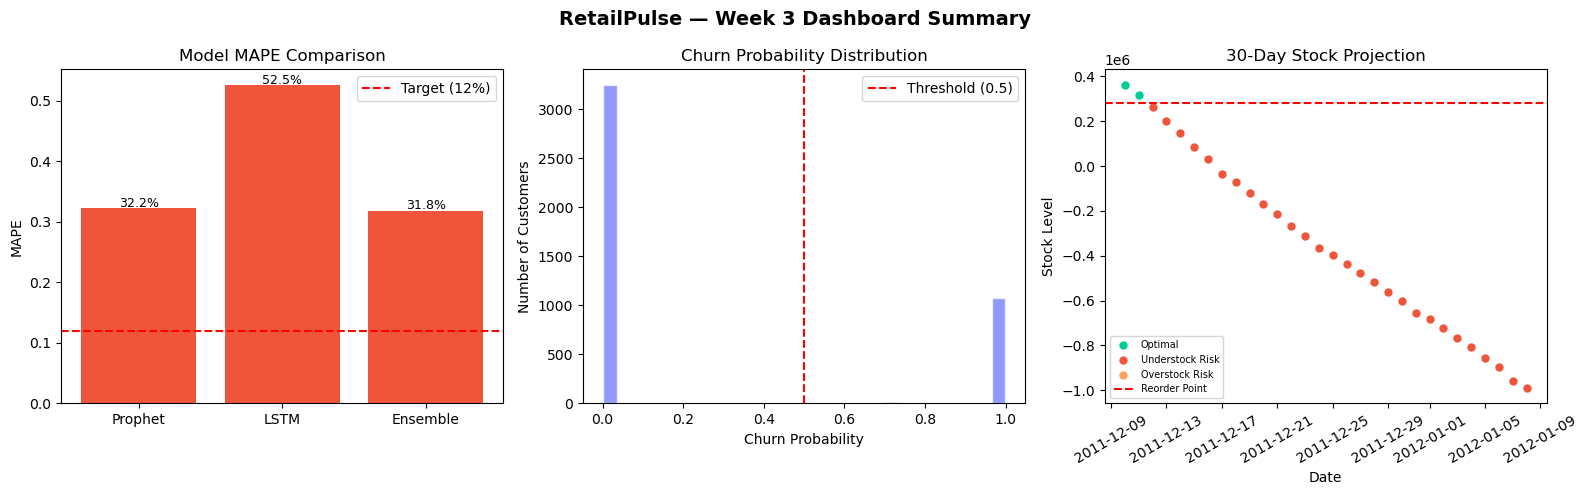

Summary chart saved to ../reports/week3_dashboard_summary.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Model MAPE comparison
models = ensemble_metrics["Model"]
mapes  = ensemble_metrics["MAPE"]
colors = ["#00CC96" if m <= 0.12 else "#EF553B" for m in mapes]
axes[0].bar(models, mapes, color=colors)
axes[0].axhline(0.12, color="red", linestyle="--", label="Target (12%)")
axes[0].set_title("Model MAPE Comparison")
axes[0].set_ylabel("MAPE")
axes[0].legend()
for i, v in enumerate(mapes):
    axes[0].text(i, v + 0.002, f"{v:.1%}", ha="center", fontsize=9)

# Plot 2: Churn probability distribution
axes[1].hist(
    churn_predictions["ChurnProbability_Tuned"],
    bins=30, color="#636EFA", alpha=0.7, edgecolor="white"
)
axes[1].axvline(0.5, color="red", linestyle="--", label="Threshold (0.5)")
axes[1].set_title("Churn Probability Distribution")
axes[1].set_xlabel("Churn Probability")
axes[1].set_ylabel("Number of Customers")
axes[1].legend()

# Plot 3: Inventory stock projection
inventory_proj["ds"] = pd.to_datetime(inventory_proj["ds"])
status_colors = {"Optimal": "#00CC96", "Understock Risk": "#EF553B", "Overstock Risk": "#FFA15A"}
for status, color in status_colors.items():
    subset = inventory_proj[inventory_proj["StockStatus"] == status]
    axes[2].scatter(subset["ds"], subset["ProjectedStock"],
                    color=color, label=status, s=25)
reorder_val = float(inventory_summary.loc[
    inventory_summary["Metric"] == "Reorder Point", "Value"
].values[0])
axes[2].axhline(reorder_val, color="red", linestyle="--", label="Reorder Point")
axes[2].set_title("30-Day Stock Projection")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Stock Level")
axes[2].legend(fontsize=7)
axes[2].tick_params(axis="x", rotation=30)

plt.suptitle("RetailPulse — Week 3 Dashboard Summary", fontsize=14, fontweight="bold")

plt.tight_layout()

plt.savefig("../reports/week3_dashboard_summary.png", dpi=150, bbox_inches="tight")

plt.show()

print("Summary chart saved to ../reports/week3_dashboard_summary.png")

In [10]:
week3_summary = pd.DataFrame({
    "Day": [15, 16, 17, 18, 19, 20],
    "Deliverable": [
        "Streamlit multi-page skeleton + data_loader.py",
        "Demand Forecasting page (Plotly + what-if analysis)",
        "Customer Segmentation & Churn Risk page",
        "Inventory Optimization page (live recalculation)",
        "Metrics & Alerts page (drift + retraining status)",
        "Export Reports page (CSV downloads + HTML/PDF report)"
    ],
    "Status": ["✅ Complete"] * 6
})

week3_summary.to_csv("../data/week3_checkpoint_summary.csv", index=False)

week3_summary

,Day,Deliverable,Status
0,15,Streamlit multi-page skeleton + data_loader.py,✅ Complete
1,16,Demand Forecasting page (Plotly + what-if anal...,✅ Complete
2,17,Customer Segmentation & Churn Risk page,✅ Complete
3,18,Inventory Optimization page (live recalculation),✅ Complete
4,19,Metrics & Alerts page (drift + retraining status),✅ Complete
5,20,Export Reports page (CSV downloads + HTML/PDF ...,✅ Complete


# Week 3 Achievements

### Completed Tasks

1. **Day 15** — Built the Streamlit multi-page dashboard skeleton with centralised `data_loader.py`, sidebar navigation, and 4 placeholder pages. Home page shows live KPI cards from Week 2 CSVs.

2. **Day 16** — Demand Forecasting page: historical vs ensemble chart (with Prophet CI toggle), 30-day future forecast with 3-model overlay, model comparison bar chart with MAPE target line, and interactive what-if demand multiplier slider with adjusted order quantity output.

3. **Day 17** — Customer Segmentation & Churn page: RFM segment bar + pie + scatter + box charts, churn probability histogram with adjustable threshold, customer risk map scatter, top-N at-risk customers table with colour-coded risk scores, feature importance bar chart.

4. **Day 18** — Inventory Optimization page: live sidebar recalculation (lead time, service level, current stock), stock health gauge, 30-day projection chart with reorder/safety/overstock reference lines, reorder alert banner, stock status donut + bar charts, recommendations card.

5. **Day 19** — Metrics & Alerts page: live alert banners driven by sidebar thresholds, model performance radar chart (actual vs target), feature drift K-S p-value bar chart, drift share donut, retraining log table, MLOps pipeline architecture.

6. **Day 20** — Export Reports page: 13 individual CSV download buttons, styled HTML report generator covering all four modules (open in browser → Ctrl+P → Save as PDF).

### Dashboard File Inventory

- `retailpulse_dashboard/app.py` — Home page
- `retailpulse_dashboard/utils/data_loader.py` — Centralised data loader
- `retailpulse_dashboard/pages/1_Demand_Forecasting.py`
- `retailpulse_dashboard/pages/2_Customer_Segmentation.py`
- `retailpulse_dashboard/pages/3_Inventory_Optimization.py`
- `retailpulse_dashboard/pages/4_Metrics_and_Alerts.py`
- `retailpulse_dashboard/pages/5_Export_Reports.py`
- `retailpulse_dashboard/requirements.txt`
- `data/week3_checkpoint_summary.csv`
- `reports/week3_dashboard_summary.png`

### Next Steps (Week 4)

- Day 22: Docker multi-stage build
- Day 23: Kubernetes manifests
- Day 24: GitHub Actions CI/CD pipeline
- Day 25: Cloud deployment (AWS/GCP or Streamlit Cloud)
- Day 26: Monitoring with Prometheus and Grafana
- Day 27: Load testing and final accuracy validation
- Day 28: Final QA, README polish, demo video, PDF report